In [ ]:
from google.colab import files

uploaded = files.upload()

Saving adult.zip to adult.zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/adult_data')

print("Extracted files:")
print(os.listdir('/content/adult_data'))

Extracted files:
['adult.names', 'Index', 'adult.data', 'old.adult.names', 'adult.test']


In [ ]:
import pandas as pd

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    '/content/adult_data/adult.data',
    names=columns,
    skipinitialspace=True
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nIncome distribution:")
print(df["income"].value_counts())

print("\nSex distribution:")
print(df["sex"].value_counts())

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Income distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Sex distribution:
sex
Male      21790
Female    10771
Name: count, dtype: int64


In [ ]:
for column in df.columns:
    count = (df[column] == "?").sum()
    if count > 0:
        print(column, ":", count)

workclass : 1836
occupation : 1843
native_country : 583


In [ ]:
categorical_columns = [
    "workclass",
    "occupation",
    "native_country"
]

for column in categorical_columns:
    df[column] = df[column].replace("?", df[column].mode()[0])

print("Remaining ? values:")
print((df == "?").sum().sum())

Remaining ? values:
0


In [ ]:
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print(df["income"].value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


In [ ]:
X = df.drop("income", axis=1)
y = df["income"]

sensitive = df["sex"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSensitive feature:")
print(sensitive.value_counts())

X shape: (32561, 14)
y shape: (32561,)

Sensitive feature:
sex
Male      21790
Female    10771
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 26048
Testing samples: 6513


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 14
Processed features: 105


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Performance
------------------
Accuracy : 0.8578
Precision: 0.7374
Recall   : 0.6358
F1 Score : 0.6829


In [ ]:
results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "sex": sensitive_test.values
})

for group in results_df["sex"].unique():
    group_data = results_df[results_df["sex"] == group]

    accuracy = accuracy_score(group_data["actual"], group_data["predicted"])
    precision = precision_score(group_data["actual"], group_data["predicted"], zero_division=0)
    recall = recall_score(group_data["actual"], group_data["predicted"], zero_division=0)
    f1 = f1_score(group_data["actual"], group_data["predicted"], zero_division=0)

    print(f"\n{group}")
    print("----------------")
    print(f"Samples   : {len(group_data)}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")


Male
----------------
Samples   : 4355
Accuracy  : 0.8211
Precision : 0.7337
Recall    : 0.6455
F1 Score  : 0.6868

Female
----------------
Samples   : 2158
Accuracy  : 0.9319
Precision : 0.7606
Recall    : 0.5837
F1 Score  : 0.6605


In [ ]:
from sklearn.metrics import confusion_matrix

fairness_results = []

for group in results_df["sex"].unique():
    group_data = results_df[results_df["sex"] == group]

    actual = group_data["actual"]
    predicted = group_data["predicted"]

    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()

    selection_rate = (predicted == 1).mean()
    true_positive_rate = tp / (tp + fn)

    fairness_results.append({
        "Group": group,
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate
    })

fairness_df = pd.DataFrame(fairness_results)

print(fairness_df)

    Group  Selection Rate  True Positive Rate
0    Male        0.267279            0.645503
1  Female        0.087118            0.583673


In [ ]:
male_rate = fairness_df.loc[fairness_df["Group"] == "Male", "Selection Rate"].iloc[0]
female_rate = fairness_df.loc[fairness_df["Group"] == "Female", "Selection Rate"].iloc[0]

male_tpr = fairness_df.loc[fairness_df["Group"] == "Male", "True Positive Rate"].iloc[0]
female_tpr = fairness_df.loc[fairness_df["Group"] == "Female", "True Positive Rate"].iloc[0]

demographic_parity_difference = abs(male_rate - female_rate)
demographic_parity_ratio = min(male_rate, female_rate) / max(male_rate, female_rate)

equal_opportunity_difference = abs(male_tpr - female_tpr)

disparate_impact = min(male_rate, female_rate) / max(male_rate, female_rate)

print("Fairness Metrics")
print("----------------")
print(f"Demographic Parity Difference : {demographic_parity_difference:.4f}")
print(f"Demographic Parity Ratio      : {demographic_parity_ratio:.4f}")
print(f"Equal Opportunity Difference  : {equal_opportunity_difference:.4f}")
print(f"Disparate Impact Ratio        : {disparate_impact:.4f}")

Fairness Metrics
----------------
Demographic Parity Difference : 0.1802
Demographic Parity Ratio      : 0.3259
Equal Opportunity Difference  : 0.0618
Disparate Impact Ratio        : 0.3259


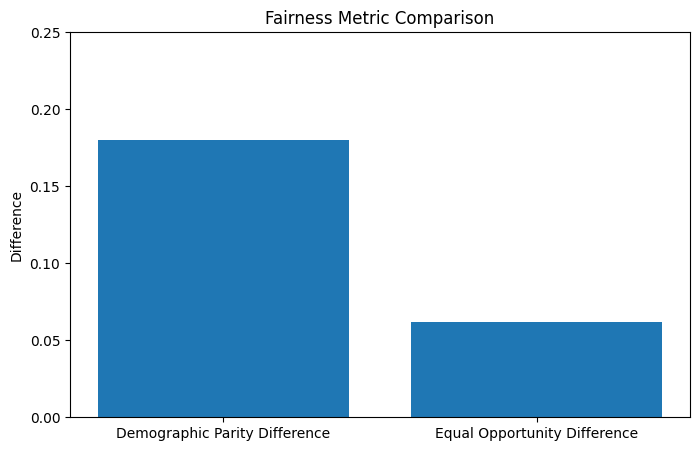

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Demographic Parity Difference",
    "Equal Opportunity Difference"
]

values = [
    demographic_parity_difference,
    equal_opportunity_difference
]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylabel("Difference")
plt.title("Fairness Metric Comparison")
plt.ylim(0, 0.25)

plt.show()

In [ ]:
X_train_no_sex = X_train.drop("sex", axis=1)
X_test_no_sex = X_test.drop("sex", axis=1)

categorical_no_sex = X_train_no_sex.select_dtypes(include=["object"]).columns
numerical_no_sex = X_train_no_sex.select_dtypes(exclude=["object"]).columns

preprocessor_no_sex = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_no_sex),
        ("num", "passthrough", numerical_no_sex)
    ]
)

X_train_no_sex_processed = preprocessor_no_sex.fit_transform(X_train_no_sex)
X_test_no_sex_processed = preprocessor_no_sex.transform(X_test_no_sex)

model_no_sex = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_no_sex.fit(X_train_no_sex_processed, y_train)

y_pred_no_sex = model_no_sex.predict(X_test_no_sex_processed)

print("Model without sex trained successfully!")
print("Processed features:", X_train_no_sex_processed.shape[1])

Model without sex trained successfully!
Processed features: 103


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "With Sex": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Without Sex": [
        accuracy_score(y_test, y_pred_no_sex),
        precision_score(y_test, y_pred_no_sex),
        recall_score(y_test, y_pred_no_sex),
        f1_score(y_test, y_pred_no_sex)
    ]
})

print(models_comparison.round(4))

      Metric  With Sex  Without Sex
0   Accuracy    0.8578       0.8564
1  Precision    0.7374       0.7346
2     Recall    0.6358       0.6320
3   F1 Score    0.6829       0.6795


In [ ]:
results_no_sex = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_no_sex,
    "sex": sensitive_test.values
})

fairness_no_sex = []

for group in results_no_sex["sex"].unique():
    group_data = results_no_sex[results_no_sex["sex"] == group]

    tn, fp, fn, tp = confusion_matrix(
        group_data["actual"],
        group_data["predicted"],
        labels=[0, 1]
    ).ravel()

    selection_rate = (group_data["predicted"] == 1).mean()
    true_positive_rate = tp / (tp + fn)

    fairness_no_sex.append({
        "Group": group,
        "Selection Rate": selection_rate,
        "True Positive Rate": true_positive_rate
    })

fairness_no_sex_df = pd.DataFrame(fairness_no_sex)

print(fairness_no_sex_df)

    Group  Selection Rate  True Positive Rate
0    Male        0.264294            0.639456
1  Female        0.091752            0.591837


In [ ]:
import joblib

joblib.dump(model, "bias_analyzer_model.pkl")
joblib.dump(preprocessor, "bias_analyzer_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
